In [168]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Testing**

For an Arbitrary Starting point from landmark Detection...

In [169]:
import numpy as np
import matplotlib.pyplot as plt

dx = -120
dy = 50
Hypotenuse Euclidean Dist = 130.0
Adjacent Euclidean Dist = 120
Angle = 157.38013505195957 degrees


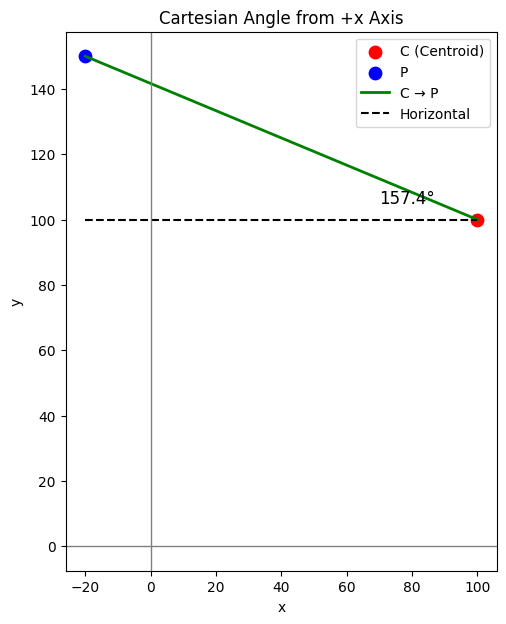

In [170]:
# Known point: centroid
C = np.array([100, 100])

# Arbitrary point
P = np.array([-20, 150])

# Vector C → P
dx = P[0] - C[0]
dy = P[1] - C[1]

# Euclidean distance
hypotenuse = np.sqrt(dx**2 + dy**2)

# Horizontal distance
adjacent = abs(dx)

# Angle from +x axis, anticlockwise
angle = np.arctan2(dy, dx)
angle_deg = np.degrees(angle)

print("dx =", dx)
print("dy =", dy)
print("Hypotenuse Euclidean Dist =", hypotenuse)
print("Adjacent Euclidean Dist =", adjacent)
print("Angle =", angle_deg, "degrees")


# =========================
# Cartesian plot
# =========================
fig, ax = plt.subplots(figsize=(7, 7))

# Point C
ax.scatter(
    C[0], C[1],
    color='red',
    s=80,
    label='C (Centroid)'
)

# Point P
ax.scatter(
    P[0], P[1],
    color='blue',
    s=80,
    label='P'
)

# Line C → P
ax.plot(
    [C[0], P[0]],
    [C[1], P[1]],
    color='green',
    linewidth=2,
    label='C → P'
)

# Horizontal line through C
ax.plot(
    [P[0], C[0]],
    [C[1], C[1]],
    '--',
    color='black',
    label='Horizontal'
)

# Angle label
ax.text(
    C[0] - 30,
    C[1] + 5,
    f'{angle_deg:.1f}°',
    fontsize=12
)

# Cartesian x and y axes
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(0, color='gray', linewidth=1)

# IMPORTANT: Cartesian orientation
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('Cartesian Angle from +x Axis')

ax.legend()

plt.show()

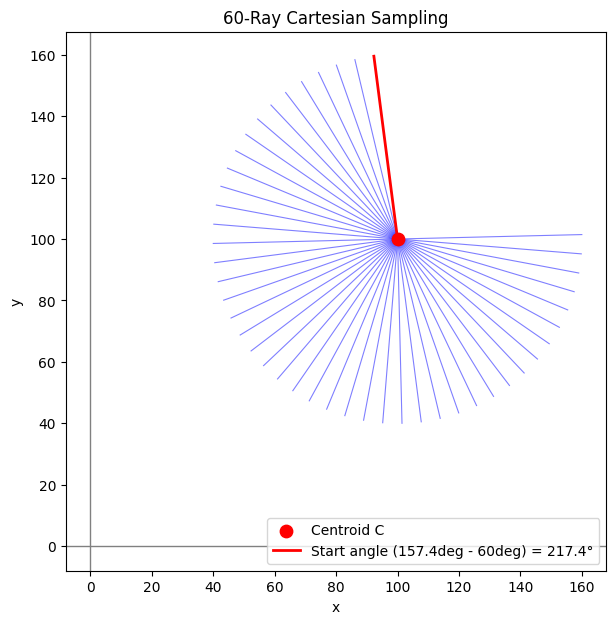

In [171]:
num_rays = 60

start_angle = (angle_deg - 60) * np.pi/180

angles = start_angle + np.linspace(0, 2*np.pi, num_rays, endpoint=False)

directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)

# Length of rays for visualization
ray_length = 60

fig, ax = plt.subplots(figsize=(7, 7))

# Centroid
ax.scatter(
    C[0], C[1],
    color='red',
    s=80,
    zorder=3,
    label='Centroid C'
)

# Plot all sampling rays
for i in range(num_rays-15):

    end_point = C + ray_length * directions[i]

    ax.plot(
        [C[0], end_point[0]],
        [C[1], end_point[1]],
        color='blue',
        linewidth=0.8,
        alpha=0.5
    )

# Mark the first ray
first_end = C + ray_length * directions[0]

ax.plot(
    [C[0], first_end[0]],
    [C[1], first_end[1]],
    color='red',
    linewidth=2,
    label=f'Start angle (157.4deg - 60deg) = {(angle_deg+60.0):.1f}°'
)

# Cartesian axes
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(0, color='gray', linewidth=1)

ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.set_title('60-Ray Cartesian Sampling')

ax.legend()

plt.show()

# Test Load Mask & Test Load Radial Strain

In [172]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [173]:
nii = nib.load("/content/drive/MyDrive/0-dataset/acdc/nifti/training/patient001/patient001_frame12_gt.nii.gz") #load GT masks
mask_data = nii.get_fdata()

In [174]:
classes = np.unique(mask_data) #class checking
print(classes)

[0. 1. 2. 3.]


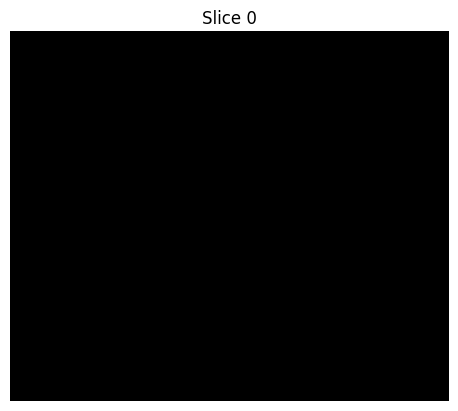

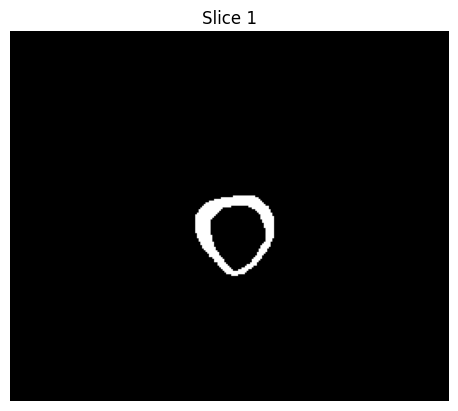

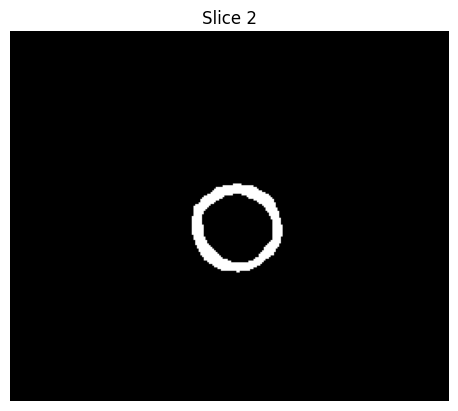

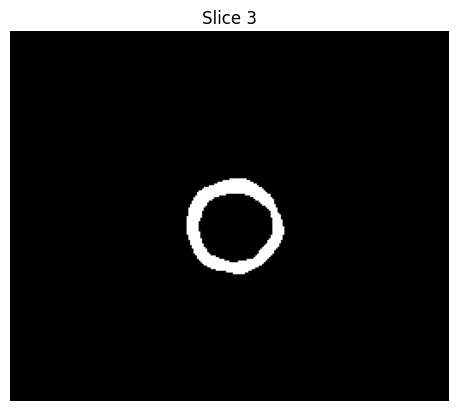

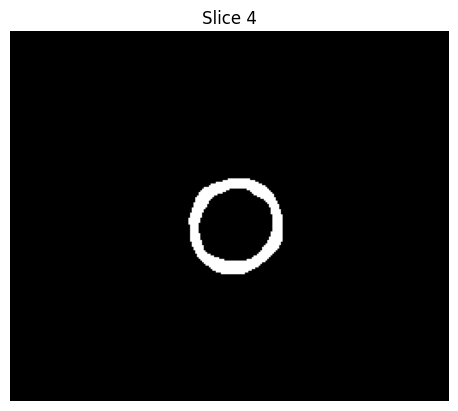

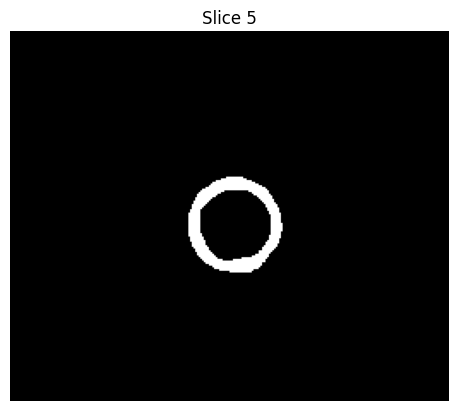

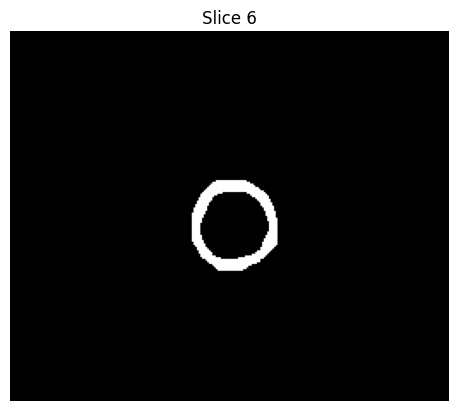

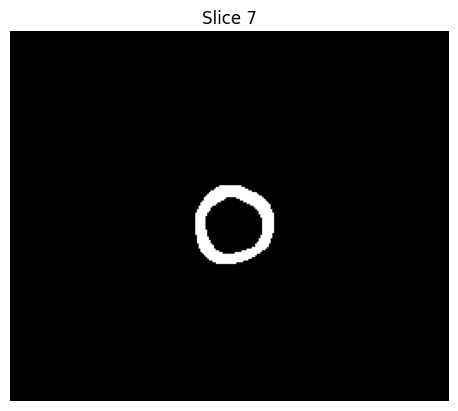

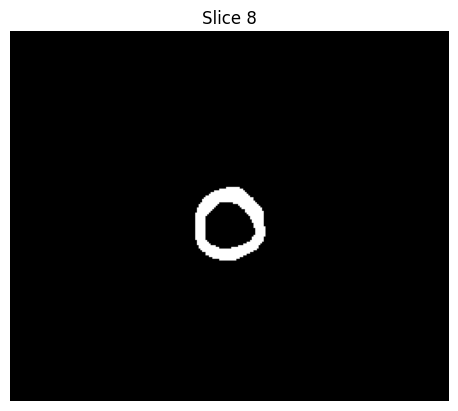

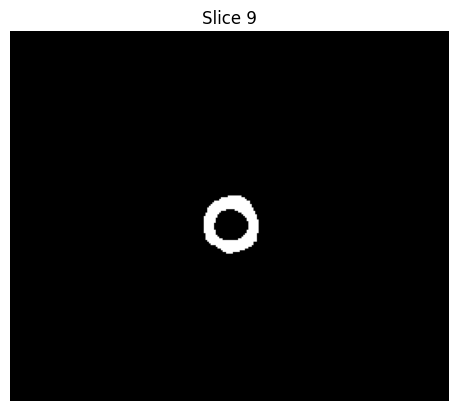

In [175]:
for i in range(mask_data.shape[2]):
    plt.imshow(mask_data[:, :, i]==2, cmap='gray', origin='lower')
    plt.title(f"Slice {i}")
    plt.axis('off')
    plt.show()

In [176]:
slice_idx = 3 #select a slice

slice_mask = (mask_data[:, :, slice_idx] == 2).astype(np.uint8) * 255

contours, hierarchy = cv2.findContours( #obtain conotours
    slice_mask,
    cv2.RETR_CCOMP,   # important: keeps holes
    cv2.CHAIN_APPROX_NONE
)

hierarchy = hierarchy[0]

outer_contour = None
inner_contours = []

for i, h in enumerate(hierarchy):
    # h = [next, prev, child, parent]
    if h[3] == -1:
        outer_contour = contours[i].squeeze()
    else:
        inner_contours.append(contours[i].squeeze())

inner_contour = max(inner_contours, key=cv2.contourArea).squeeze()

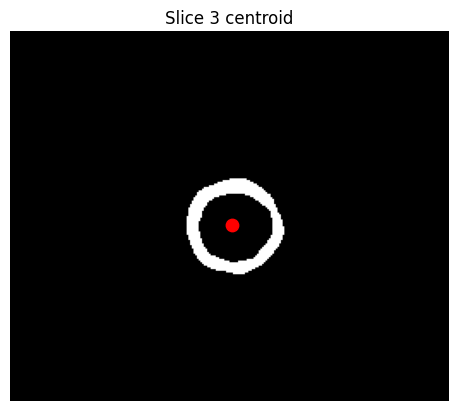

In [177]:
class_id = 2 #select myo
slice_idx = 3

# binary mask for that slice
slice_mask = (mask_data[:, :, slice_idx] == class_id).astype(np.uint8) * 255 #need this conversion else moments cannot work

# compute moments
M = cv2.moments(slice_mask)

if M["m00"] != 0:
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
else:
    cx, cy = None, None


plt.imshow(slice_mask, cmap='gray', origin='lower')

if cx is not None:
    plt.scatter(cx, cy, c='red', s=80)

plt.title(f"Slice {slice_idx} centroid")
plt.axis('off')
plt.show()

## **Get Centroid**

In [178]:
slice_idx = 3
class_id = 2

mask = (mask_data[:, :, slice_idx] == class_id).astype(np.uint8)

M = cv2.moments(mask * 255)

cx = M["m10"] / M["m00"]
cy = M["m01"] / M["m00"]

center = np.array([cx, cy])

In [179]:
def ray_intersect(mask, center, direction, max_len=500):
    h, w = mask.shape

    for r in range(1, max_len):
        x = int(center[0] + r * direction[0])
        y = int(center[1] + r * direction[1])

        if x < 0 or x >= w or y < 0 or y >= h:
            return None

        val = mask[y, x]

        # return first meaningful hit (example: entering myocardium)
        if val == 1:
            return (x, y, r)

    return None

In [180]:
# num_rays = 30

# # start_angle = 0

# start_angle = -np.pi/6 # start from 330 deg/-30 degree, then gp anticlockwise

# angles = start_angle - np.linspace(0, 2*np.pi, num_rays, endpoint=False)

# directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)

In [181]:
num_rays = 60

angle_deg = 60 # or the angle derived from arbitrary point P

start_angle = (angle_deg - 60) * np.pi/180

angles = start_angle + np.linspace(0, 2*np.pi, num_rays, endpoint=False)

directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)

In [182]:
outer_pts = []
inner_pts = []

for d in directions:

    transitions = []

    prev = mask[int(cy), int(cx)]

    for r in range(1, 500): # radial distance in pixels, ensure the'steps' reach the inner boundary
        x = int(cx + r * d[0])
        y = int(cy + r * d[1])

        if x < 0 or x >= mask.shape[1] or y < 0 or y >= mask.shape[0]:
            break

        val = mask[y, x]

        if val != prev:
            transitions.append((r, val, (x, y)))
            prev = val

    # decide boundaries by distance from centroid
    if len(transitions) >= 2:
        p1 = transitions[0][2]
        p2 = transitions[1][2]

        # distance to centroid
        d1 = np.linalg.norm(np.array(p1) - [cx, cy])
        d2 = np.linalg.norm(np.array(p2) - [cx, cy])

        # inner = closer, outer = farther
        if d1 < d2:
            inner_pts.append(p1)
            outer_pts.append(p2)
        else:
            inner_pts.append(p2)
            outer_pts.append(p1)

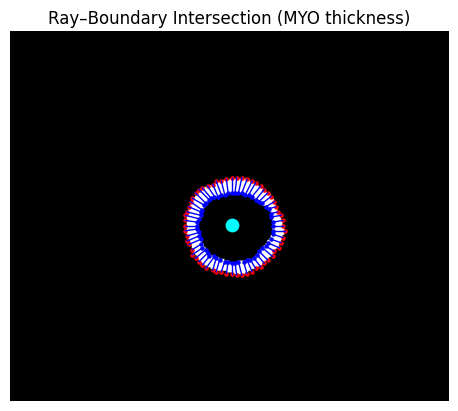

In [183]:
plt.imshow(mask, cmap='gray', origin='lower')

plt.scatter(cx, cy, c='cyan', s=80)

outer_pts = np.array(outer_pts)
inner_pts = np.array(inner_pts)

# plt.scatter(outer_pts[0:2,0], outer_pts[0:2,1], c='yellow', s=5)

plt.scatter(outer_pts[0:,0], outer_pts[0:,1], c='red', s=5)
plt.scatter(inner_pts[0:,0], inner_pts[0:,1], c='blue', s=5)

for i in range(len(outer_pts)):
    plt.plot(
        [outer_pts[i][0], inner_pts[i][0]],
        [outer_pts[i][1], inner_pts[i][1]],
        'blue', linewidth=1.0
    )

plt.title("Ray–Boundary Intersection (MYO thickness)")
plt.axis('off')
plt.show()

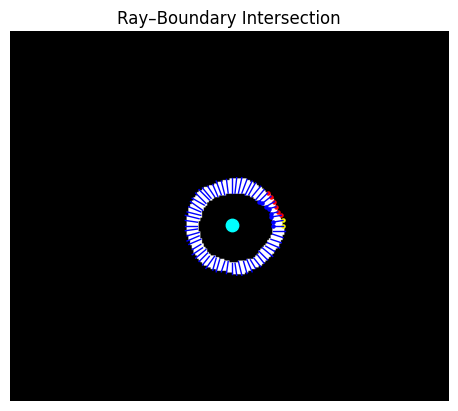

In [184]:
plt.imshow(mask, cmap='gray', origin='lower')

plt.scatter(cx, cy, c='cyan', s=80)

outer_pts = np.array(outer_pts)
inner_pts = np.array(inner_pts)

plt.scatter(outer_pts[0:2,0], outer_pts[0:2,1], c='yellow', s=5)

plt.scatter(outer_pts[2:8,0], outer_pts[2:8,1], c='red', s=5)
plt.scatter(inner_pts[:8,0], inner_pts[:8,1], c='blue', s=5)

for i in range(len(outer_pts)):
    plt.plot(
        [outer_pts[i][0], inner_pts[i][0]],
        [outer_pts[i][1], inner_pts[i][1]],
        'blue', linewidth=1.0
    )

plt.title("Ray–Boundary Intersection")
plt.axis('off')
plt.show()

In [185]:
outer_np = np.array(outer_pts)  # shape (N, 2)
inner_np = np.array(inner_pts)  # shape (N, 2)
diff = outer_np - inner_np
distances = np.sqrt((diff[:, 0]**2 + diff[:, 1]**2)) # euclidean distance
print(distances) # get the sampled myo radial distance between inner and outer boundary
print(distances.shape)

[6.         6.08276253 6.08276253 4.12310563 4.12310563 5.83095189
 6.40312424 7.07106781 7.81024968 7.81024968 8.06225775 8.94427191
 8.54400375 9.21954446 9.05538514 9.         8.06225775 8.24621125
 8.54400375 7.61577311 7.21110255 7.81024968 8.48528137 8.48528137
 8.06225775 8.60232527 7.61577311 8.24621125 8.24621125 7.07106781
 7.         7.07106781 7.28010989 7.61577311 7.61577311 5.83095189
 7.21110255 7.81024968 7.07106781 6.40312424 8.60232527 7.28010989
 7.28010989 6.32455532 7.07106781 6.         7.07106781 8.24621125
 7.28010989 7.61577311 5.83095189 6.40312424 6.40312424 7.07106781
 7.81024968 5.83095189 7.61577311 6.32455532 6.32455532 7.        ]
(60,)


In [186]:
grouped = distances.reshape(-1, 10)
group_means = grouped.mean(axis=1)
print(group_means) ##60 rays, group every 10 into 1 group, group into the 6 groups per the 2D AHA Model
print(group_means.shape) #group into the 6 groups per the 2D AHA Model

[6.13373796 8.52937088 7.98357614 7.09092201 7.27713302 6.66143535]
(6,)


## **Plot for 4 groups (inner) - sample 40 points**

In [187]:
num_rays = 40

# start_angle = 0

start_angle = (angle_deg - 75) * np.pi/180

angles = start_angle + np.linspace(0, 2*np.pi, num_rays, endpoint=False)

directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)

In [188]:
outer_pts = []
inner_pts = []

for d in directions:

    transitions = []

    prev = mask[int(cy), int(cx)]

    for r in range(1, 500): # radial distance in pixels, ensure the'steps' reach the inner boundary
        x = int(cx + r * d[0])
        y = int(cy + r * d[1])

        if x < 0 or x >= mask.shape[1] or y < 0 or y >= mask.shape[0]:
            break

        val = mask[y, x]

        if val != prev:
            transitions.append((r, val, (x, y)))
            prev = val

    # decide boundaries by distance from centroid
    if len(transitions) >= 2:
        p1 = transitions[0][2]
        p2 = transitions[1][2]

        # distance to centroid
        d1 = np.linalg.norm(np.array(p1) - [cx, cy])
        d2 = np.linalg.norm(np.array(p2) - [cx, cy])

        # inner = closer, outer = farther
        if d1 < d2:
            inner_pts.append(p1)
            outer_pts.append(p2)
        else:
            inner_pts.append(p2)
            outer_pts.append(p1)

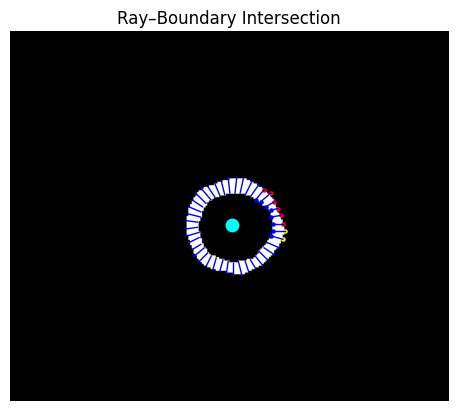

In [189]:
plt.imshow(mask, cmap='gray', origin='lower')

plt.scatter(cx, cy, c='cyan', s=80)

outer_pts = np.array(outer_pts)
inner_pts = np.array(inner_pts)

plt.scatter(outer_pts[0:2,0], outer_pts[0:2,1], c='yellow', s=5)

plt.scatter(outer_pts[2:8,0], outer_pts[2:8,1], c='red', s=5)
plt.scatter(inner_pts[0:8,0], inner_pts[0:8,1], c='blue', s=5)

for i in range(len(outer_pts)):
    plt.plot(
        [outer_pts[i][0], inner_pts[i][0]],
        [outer_pts[i][1], inner_pts[i][1]],
        'blue', linewidth=1.0
    )

plt.title("Ray–Boundary Intersection")
plt.axis('off')
plt.show()

In [190]:
outer_np = np.array(outer_pts)  # shape (N, 2)
inner_np = np.array(inner_pts)  # shape (N, 2)
diff = outer_np - inner_np
distances = np.sqrt((diff[:, 0]**2 + diff[:, 1]**2)) # euclidean distance
print(distances)

print("================")

grouped = distances.reshape(-1, 10)
group_means = grouped.mean(axis=1)
print(group_means) # get the 60 distances

[7.28010989 7.         6.         6.08276253 4.12310563 5.83095189
 7.81024968 7.81024968 8.60232527 8.94427191 9.21954446 9.05538514
 9.05538514 8.24621125 7.61577311 7.21110255 9.21954446 8.48528137
 7.21110255 7.61577311 8.24621125 7.07106781 7.07106781 7.28010989
 6.70820393 5.83095189 7.81024968 7.07106781 6.70820393 7.28010989
 7.28010989 7.07106781 7.         8.24621125 6.32455532 5.83095189
 6.40312424 7.07106781 7.21110255 7.61577311]
[6.94840265 8.29351031 7.10772439 7.00539639]


# Circumferential Strain

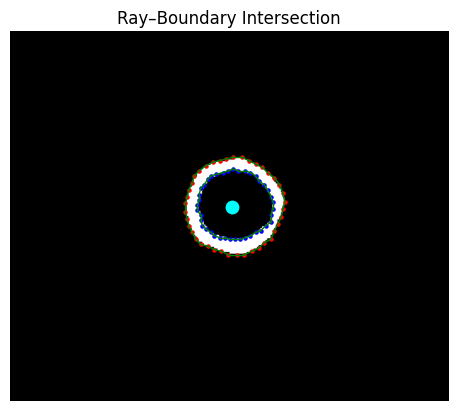

In [191]:
plt.imshow(mask, cmap='gray')

plt.scatter(cx, cy, c='cyan', s=80)

outer_pts = np.array(outer_pts)
inner_pts = np.array(inner_pts)

plt.scatter(outer_pts[:,0], outer_pts[:,1], c='red', s=5)
plt.scatter(inner_pts[:,0], inner_pts[:,1], c='blue', s=5)

for i in range(len(outer_pts)):
    c = i+1
    if c >= len(outer_pts):
      c = 0

    plt.plot(
        [outer_pts[i][0], outer_pts[c][0]], [outer_pts[i][1], outer_pts[c][1]],
        'green', linewidth=1.0
    )

    plt.plot(
        [inner_pts[i][0], inner_pts[c][0]], [inner_pts[i][1], inner_pts[c][1]],
        'green', linewidth=1.0
    )

plt.title("Ray–Boundary Intersection")
plt.axis('off')
plt.show()

In [192]:
outer_np = np.array(outer_pts)  # shape (N, 2)
inner_np = np.array(inner_pts)  # shape (N, 2)
mid_pts = (outer_np - inner_np)/2 + inner_np

print("================")
print(mid_pts.shape)

mid_np = np.array(mid_pts)

outer_circ_distances = []
inner_circ_distances = []
mid_circ_distances = []

for i in range(len(outer_pts)):
    c = i+1

    if c > 29:
      c = 0

    outer_circ_distances.append(np.sqrt((outer_np[i, 0]**2 + outer_np[c, 1]**2)))
    inner_circ_distances.append(np.sqrt((inner_np[i, 0]**2 + inner_np[c, 1]**2)))
    mid_circ_distances.append(np.sqrt((mid_np[i, 0]**2 + mid_np[c, 1]**2)))


print("================")
print(outer_circ_distances)
print(inner_circ_distances)
print(mid_circ_distances)



(40, 2)
[np.float64(187.3018953454556), np.float64(190.2866259094422), np.float64(192.21082175569617), np.float64(193.66982212001952), np.float64(194.40164608356588), np.float64(195.8494319624134), np.float64(195.5326059765992), np.float64(194.3707796969493), np.float64(193.4140636044856), np.float64(191.7837323653912), np.float64(188.13824704190267), np.float64(185.26737435393204), np.float64(180.31361568112376), np.float64(176.7993212656655), np.float64(172.58621034138272), np.float64(169.11830178901394), np.float64(164.20109622045769), np.float64(159.2262541165872), np.float64(154.93547043850222), np.float64(150.65523555456014), np.float64(147.08500943332058), np.float64(142.84257068535277), np.float64(140.07141035914503), np.float64(138.10503249338888), np.float64(136.23509092741122), np.float64(135.2479205015737), np.float64(134.2013412749664), np.float64(134.84806264830058), np.float64(137.0109484676316), np.float64(150.86417732516887), np.float64(154.01298646542764), np.float64(

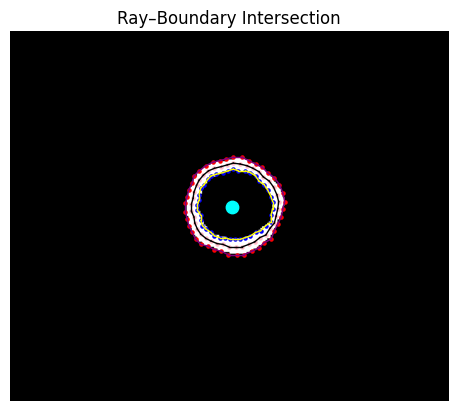

In [193]:
plt.imshow(mask, cmap='gray')

plt.scatter(cx, cy, c='cyan', s=80)

outer_pts = np.array(outer_pts)
inner_pts = np.array(inner_pts)

plt.scatter(outer_pts[:,0], outer_pts[:,1], c='red', s=5)
plt.scatter(inner_pts[:,0], inner_pts[:,1], c='blue', s=5)
plt.scatter(mid_pts[:,0], mid_pts[:,1], c='pink', s=5)

for i in range(len(outer_pts)):
    c = i+1
    if c >= len(outer_pts):
      c = 0

    plt.plot(
        [outer_pts[i][0], outer_pts[c][0]], [outer_pts[i][1], outer_pts[c][1]],
        'purple', linewidth=1.0
    )

    plt.plot(
        [inner_pts[i][0], inner_pts[c][0]], [inner_pts[i][1], inner_pts[c][1]],
        'yellow', linewidth=1.0
    )

    plt.plot(
        [mid_pts[i][0], mid_pts[c][0]], [mid_pts[i][1], mid_pts[c][1]],
        'black', linewidth=1.0
    )

plt.title("Ray–Boundary Intersection")
plt.axis('off')
plt.show()

# Frame 1 & 2 Strain
(Lagrangian Strain- reference all to ED phase)

((To check w Stephanie))

In [194]:
nii_1 = nib.load("/content/drive/MyDrive/0-dataset/acdc/nifti/training/patient001/patient001_frame01_gt.nii.gz") #load GT masks
mask_data_1 = nii_1.get_fdata()

In [195]:
nii_2 = nib.load("/content/drive/MyDrive/0-dataset/acdc/nifti/training/patient001/patient001_frame12_gt.nii.gz") #load GT masks
mask_data_2 = nii_2.get_fdata()

In [196]:
slice_idx = 3
class_id = 2

mask_1 = (mask_data_1[:, :, slice_idx] == class_id).astype(np.uint8)

M_1 = cv2.moments(mask_1 * 255)

cx_1 = M_1["m10"] / M_1["m00"]
cy_1 = M_1["m01"] / M_1["m00"]

center_1 = np.array([cx_1, cy_1])

#==================================================

mask_2 = (mask_data_2[:, :, slice_idx] == class_id).astype(np.uint8)

M_2 = cv2.moments(mask_2 * 255)

cx_2 = M_2["m10"] / M_2["m00"]
cy_2 = M_2["m01"] / M_2["m00"]

center_2 = np.array([cx_2, cy_2])

In [197]:
slice_mask_1 = (mask_data_1[:, :, slice_idx] == 2).astype(np.uint8) * 255

contours, hierarchy = cv2.findContours( #obtain conotours
    slice_mask_1,
    cv2.RETR_CCOMP,   # important: keeps holes
    cv2.CHAIN_APPROX_NONE
)

hierarchy = hierarchy[0]

outer_contour_1 = None
inner_contours_1 = []

for i, h in enumerate(hierarchy):
    # h = [next, prev, child, parent]
    if h[3] == -1:
        outer_contour_1 = contours[i].squeeze()
    else:
        inner_contours_1.append(contours[i].squeeze())

inner_contour_1 = max(inner_contours_1, key=cv2.contourArea).squeeze()

In [198]:
slice_mask_2 = (mask_data_2[:, :, slice_idx] == 2).astype(np.uint8) * 255

contours, hierarchy = cv2.findContours( #obtain conotours
    slice_mask_2,
    cv2.RETR_CCOMP,   # important: keeps holes
    cv2.CHAIN_APPROX_NONE
)

hierarchy = hierarchy[0]

outer_contour_2 = None
inner_contours_2 = []

for i, h in enumerate(hierarchy):
    # h = [next, prev, child, parent]
    if h[3] == -1:
        outer_contour_2 = contours[i].squeeze()
    else:
        inner_contours_2.append(contours[i].squeeze())

inner_contour_2 = max(inner_contours_2, key=cv2.contourArea).squeeze()

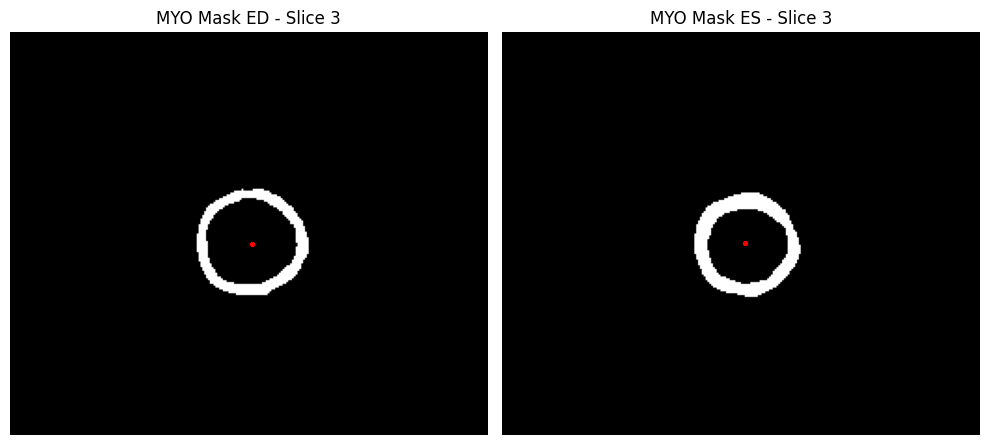

In [199]:
# Create two plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: mask
axes[0].imshow(slice_mask_1, cmap='gray', origin='lower')

if cx_1 is not None:
    axes[0].scatter(cx_1, cy_1, c='red', s=8)

axes[0].set_title(f"MYO Mask ED - Slice {slice_idx}")
axes[0].axis('off')

# Plot 2: mask + centroid
axes[1].imshow(slice_mask_2, cmap='gray', origin='lower')

if cx_2 is not None:
    axes[1].scatter(cx_2, cy_2, c='red', s=8)

axes[1].set_title(f"MYO Mask ES - Slice {slice_idx}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [200]:
def ray_intersect(mask, center, direction, max_len=500): # get ray intersection
    h, w = mask.shape

    for r in range(1, max_len):
        x = int(center[0] + r * direction[0])
        y = int(center[1] + r * direction[1])

        if x < 0 or x >= w or y < 0 or y >= h:
            return None

        val = mask[y, x]

        # return first meaningful hit (example: entering myocardium)
        if val == 1:
            return (x, y, r)

    return None

In [201]:
angle_deg = np.float64(157.38013505195957)

In [202]:
num_rays = 60

# start_angle = 60 * np.pi/180 # start from 330 deg/-30 degree
# angle_deg = 60
start_angle = (angle_deg - 60) * np.pi/180 # start from 330 deg/-30 degree


angles = start_angle + np.linspace(0, 2*np.pi, num_rays, endpoint=False)

directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)

In [203]:
outer_pts_1 = []
inner_pts_1 = []

for d in directions:

    transitions = []

    prev = mask_1[int(cy_1), int(cx_1)]

    for r in range(1, 500): # radial distance in pixels, ensure the'steps' reach the inner boundary
        x = int(cx_1 + r * d[0])
        y = int(cy_1 + r * d[1])

        if x < 0 or x >= mask_1.shape[1] or y < 0 or y >= mask_1.shape[0]:
            break

        val = mask_1[y, x]

        if val != prev:
            transitions.append((r, val, (x, y)))
            prev = val

    # decide boundaries by distance from centroid
    if len(transitions) >= 2:
        p1 = transitions[0][2]
        p2 = transitions[1][2]

        # distance to centroid
        d1 = np.linalg.norm(np.array(p1) - [cx_1, cy_1])
        d2 = np.linalg.norm(np.array(p2) - [cx_1, cy_1])

        # inner = closer, outer = farther
        if d1 < d2:
            inner_pts_1.append(p1)
            outer_pts_1.append(p2)
        else:
            inner_pts_1.append(p2)
            outer_pts_1.append(p1)

In [204]:
outer_pts_2 = []
inner_pts_2 = []

for d in directions:

    transitions = []

    prev = mask_2[int(cy_2), int(cx_2)]

    for r in range(1, 500): # radial distance in pixels, ensure the'steps' reach the inner boundary
        x = int(cx_2 + r * d[0])
        y = int(cy_2 + r * d[1])

        if x < 0 or x >= mask_2.shape[1] or y < 0 or y >= mask_2.shape[0]:
            break

        val = mask_2[y, x]

        if val != prev:
            transitions.append((r, val, (x, y)))
            prev = val

    # decide boundaries by distance from centroid
    if len(transitions) >= 2:
        p1 = transitions[0][2]
        p2 = transitions[1][2]

        # distance to centroid
        d1 = np.linalg.norm(np.array(p1) - [cx_2, cy_2])
        d2 = np.linalg.norm(np.array(p2) - [cx_2, cy_2])

        # inner = closer, outer = farther
        if d1 < d2:
            inner_pts_2.append(p1)
            outer_pts_2.append(p2)
        else:
            inner_pts_2.append(p2)
            outer_pts_2.append(p1)

In [205]:
outer_pts_1 = np.array(outer_pts_1)
inner_pts_1 = np.array(inner_pts_1)

outer_pts_2 = np.array(outer_pts_2)
inner_pts_2 = np.array(inner_pts_2)

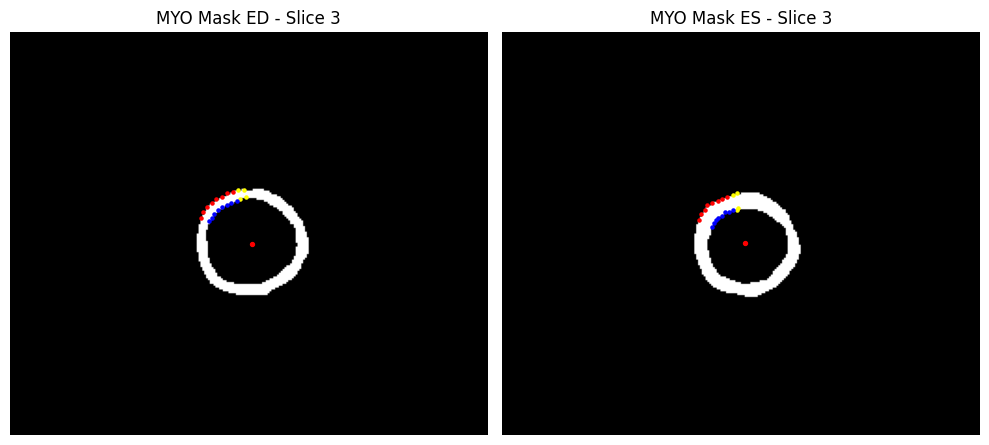

In [206]:

# Create two plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# =========================
# Plot 1: ED
# =========================
axes[0].imshow(slice_mask_1, cmap='gray', origin='lower')

axes[0].scatter(outer_pts_1[:2,0], outer_pts_1[:2,1], c='yellow', s=5)
axes[0].scatter(inner_pts_1[:2,0], inner_pts_1[:2,1], c='yellow', s=5)

axes[0].scatter(outer_pts_1[2:10,0], outer_pts_1[2:10,1], c='red', s=5)
axes[0].scatter(inner_pts_1[2:10,0], inner_pts_1[2:10,1], c='blue', s=5)


if cx_1 is not None:
    axes[0].scatter(cx_1, cy_1, c='red', s=8)


axes[0].set_title(f"MYO Mask ED - Slice {slice_idx}")
axes[0].axis('off')


# Plot 2: ES
axes[1].imshow(slice_mask_2, cmap='gray', origin='lower')

axes[1].scatter(outer_pts_2[:2,0], outer_pts_2[:2,1], c='yellow', s=5)
axes[1].scatter(inner_pts_2[:2,0], inner_pts_2[:2,1], c='yellow', s=5)

axes[1].scatter(outer_pts_2[2:10,0], outer_pts_2[2:10,1], c='red', s=5)
axes[1].scatter(inner_pts_2[2:10,0], inner_pts_2[2:10,1], c='blue', s=5)

if cx_2 is not None:
    axes[1].scatter(cx_2, cy_2, c='red', s=8)

axes[1].set_title(f"MYO Mask ES - Slice {slice_idx}")
axes[1].axis('off')




plt.tight_layout()
plt.show()

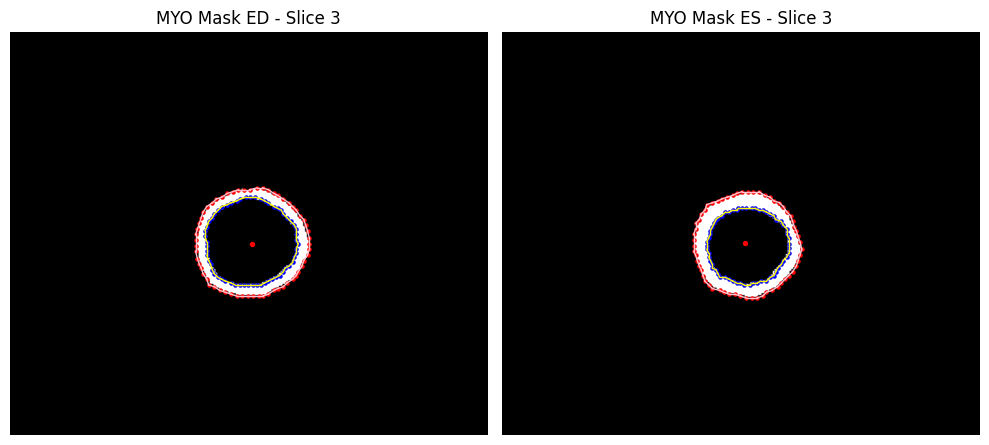

In [207]:
# Create two plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# =========================
# Plot 1: ED
# =========================
axes[0].imshow(slice_mask_1, cmap='gray', origin='lower')

axes[0].scatter(outer_pts_1[:,0], outer_pts_1[:,1], c='red', s=5)
axes[0].scatter(inner_pts_1[:,0], inner_pts_1[:,1], c='blue', s=5)


if cx_1 is not None:
    axes[0].scatter(cx_1, cy_1, c='red', s=8)

for i in range(len(outer_pts_1)):
    c = i + 1

    if c >= len(outer_pts_1):
        c = 0

    # Outer contour
    axes[0].plot(
        [outer_pts_1[i][0], outer_pts_1[c][0]],
        [outer_pts_1[i][1], outer_pts_1[c][1]],
        'Pink',
        linewidth=1.0
    )

    # Inner contour
    axes[0].plot(
        [inner_pts_1[i][0], inner_pts_1[c][0]],
        [inner_pts_1[i][1], inner_pts_1[c][1]],
        'yellow',
        linewidth=1.0
    )

axes[0].set_title(f"MYO Mask ED - Slice {slice_idx}")
axes[0].axis('off')



# Plot 2: ES
axes[1].imshow(slice_mask_2, cmap='gray', origin='lower')

axes[1].scatter(outer_pts_2[:,0], outer_pts_2[:,1], c='red', s=5)
axes[1].scatter(inner_pts_2[:,0], inner_pts_2[:,1], c='blue', s=5)

for i in range(len(outer_pts_1)):
    c = i + 1

    if c >= len(outer_pts_1):
        c = 0
        # Outer contour
    axes[1].plot(
            [outer_pts_2[i][0], outer_pts_2[c][0]],
            [outer_pts_2[i][1], outer_pts_2[c][1]],
            'pink',
            linewidth=1.0
        )

    # Inner contour
    axes[1].plot(
            [inner_pts_2[i][0], inner_pts_2[c][0]],
            [inner_pts_2[i][1], inner_pts_2[c][1]],
            'yellow',
            linewidth=1.0
        )

if cx_2 is not None:
    axes[1].scatter(cx_2, cy_2, c='red', s=8)

axes[1].set_title(f"MYO Mask ES - Slice {slice_idx}")
axes[1].axis('off')



plt.tight_layout()
plt.show()

In [208]:
# given:
# outer_pts_1 = np.array(outer_pts_1)
# inner_pts_1 = np.array(inner_pts_1)

# outer_pts_2 = np.array(outer_pts_2)
# inner_pts_2 = np.array(inner_pts_2)

mid_pts_1 = (outer_pts_1 - inner_pts_1)/2 + inner_pts_1
mid_pts_2 = (outer_pts_2 - inner_pts_2)/2 + inner_pts_2

mid_pts_1 = np.array(mid_pts_1)
mid_pts_2 = np.array(mid_pts_2)

outer_circ_distances_1 = []
inner_circ_distances_1 = []
mid_circ_distances_1 = []

outer_circ_distances_2 = []
inner_circ_distances_2 = []
mid_circ_distances_2 = []


for i in range(len(outer_pts_1)):
    c = i+1

    if c > 29:
      c = 0

    outer_circ_distances_1.append(np.sqrt((outer_pts_1[i, 0]**2 + outer_pts_1[c, 1]**2)))
    inner_circ_distances_1.append(np.sqrt((inner_pts_1[i, 0]**2 + inner_pts_1[c, 1]**2)))
    mid_circ_distances_1.append(np.sqrt((mid_pts_1[i, 0]**2 + mid_pts_1[c, 1]**2)))

    outer_circ_distances_2.append(np.sqrt((outer_pts_2[i, 0]**2 + outer_pts_2[c, 1]**2)))
    inner_circ_distances_2.append(np.sqrt((inner_pts_2[i, 0]**2 + inner_pts_2[c, 1]**2)))
    mid_circ_distances_2.append(np.sqrt((mid_pts_2[i, 0]**2 + mid_pts_2[c, 1]**2)))

print("Mask 1===============")
print(outer_circ_distances_1)
print(inner_circ_distances_1)
print(mid_circ_distances_1)

print("Mask 2===============")
print(outer_circ_distances_2)
print(inner_circ_distances_2)
print(mid_circ_distances_2)


Mask 1===============
[np.float64(181.06904760339356), np.float64(178.2806775845324), np.float64(175.50498568416796), np.float64(172.00290695217916), np.float64(169.24833824885843), np.float64(165.75886099994776), np.float64(162.9355700883021), np.float64(158.70097668256489), np.float64(155.12897859523216), np.float64(152.22680447279973), np.float64(149.33519344079613), np.float64(146.4547711752676), np.float64(143.58621103713267), np.float64(141.42842712835352), np.float64(139.30183056945089), np.float64(136.517398158623), np.float64(135.20724832641184), np.float64(134.61797799699713), np.float64(133.41664064126334), np.float64(132.2800060477773), np.float64(132.00378782444085), np.float64(132.20060514233663), np.float64(133.4541119636259), np.float64(135.35139452550905), np.float64(137.2953021774598), np.float64(139.2838827718412), np.float64(141.8344104933637), np.float64(144.40221604947757), np.float64(146.98639392814562), np.float64(184.55622449540954), np.float64(186.681547025944

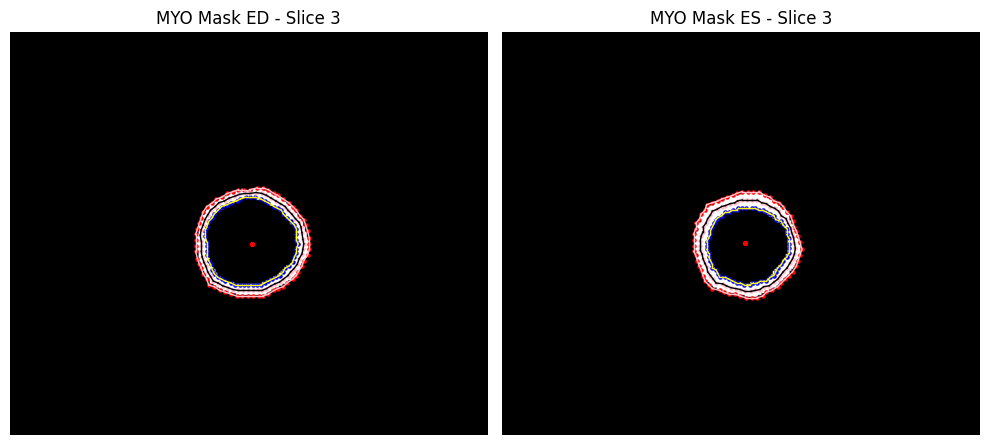

In [209]:
# Create two plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# =========================
# Plot 1: ED
# =========================
axes[0].imshow(slice_mask_1, cmap='gray', origin='lower')

axes[0].scatter(outer_pts_1[:,0], outer_pts_1[:,1], c='red', s=5)
axes[0].scatter(inner_pts_1[:,0], inner_pts_1[:,1], c='blue', s=5)
axes[0].scatter(mid_pts_1[:,0], mid_pts_1[:,1], c='pink', s=5)


if cx_1 is not None:
    axes[0].scatter(cx_1, cy_1, c='red', s=8)

for i in range(len(outer_pts_1)):
    c = i + 1

    if c >= len(outer_pts_1):
        c = 0

    # Outer contour
    axes[0].plot(
        [outer_pts_1[i][0], outer_pts_1[c][0]],
        [outer_pts_1[i][1], outer_pts_1[c][1]],
        'Pink',
        linewidth=1.0
    )

    # mid contour
    axes[0].plot(
        [mid_pts_1[i][0], mid_pts_1[c][0]],
        [mid_pts_1[i][1], mid_pts_1[c][1]],
        'black',
        linewidth=1.0
    )

    # Inner contour
    axes[0].plot(
        [inner_pts_1[i][0], inner_pts_1[c][0]],
        [inner_pts_1[i][1], inner_pts_1[c][1]],
        'yellow',
        linewidth=1.0
    )

axes[0].set_title(f"MYO Mask ED - Slice {slice_idx}")
axes[0].axis('off')



# Plot 2: ES
axes[1].imshow(slice_mask_2, cmap='gray', origin='lower')

axes[1].scatter(outer_pts_2[:,0], outer_pts_2[:,1], c='red', s=5)
axes[1].scatter(inner_pts_2[:,0], inner_pts_2[:,1], c='blue', s=5)
axes[1].scatter(mid_pts_2[:,0], mid_pts_2[:,1], c='pink', s=5)


for i in range(len(outer_pts_1)):
    c = i + 1

    if c >= len(outer_pts_1):
        c = 0
        # Outer contour
    axes[1].plot(
            [outer_pts_2[i][0], outer_pts_2[c][0]],
            [outer_pts_2[i][1], outer_pts_2[c][1]],
            'pink',
            linewidth=1.0
        )

    # mid contour
    axes[1].plot(
        [mid_pts_2[i][0], mid_pts_2[c][0]],
        [mid_pts_2[i][1], mid_pts_2[c][1]],
        'black',
        linewidth=1.0
    )

    # Inner contour
    axes[1].plot(
            [inner_pts_2[i][0], inner_pts_2[c][0]],
            [inner_pts_2[i][1], inner_pts_2[c][1]],
            'yellow',
            linewidth=1.0
        )

if cx_2 is not None:
    axes[1].scatter(cx_2, cy_2, c='red', s=8)

axes[1].set_title(f"MYO Mask ES - Slice {slice_idx}")
axes[1].axis('off')


plt.tight_layout()
plt.show()

In [210]:
print("Mask 1===============")
print(outer_circ_distances_1)
print(inner_circ_distances_1)
print(mid_circ_distances_1)

Mask 1===============
[np.float64(181.06904760339356), np.float64(178.2806775845324), np.float64(175.50498568416796), np.float64(172.00290695217916), np.float64(169.24833824885843), np.float64(165.75886099994776), np.float64(162.9355700883021), np.float64(158.70097668256489), np.float64(155.12897859523216), np.float64(152.22680447279973), np.float64(149.33519344079613), np.float64(146.4547711752676), np.float64(143.58621103713267), np.float64(141.42842712835352), np.float64(139.30183056945089), np.float64(136.517398158623), np.float64(135.20724832641184), np.float64(134.61797799699713), np.float64(133.41664064126334), np.float64(132.2800060477773), np.float64(132.00378782444085), np.float64(132.20060514233663), np.float64(133.4541119636259), np.float64(135.35139452550905), np.float64(137.2953021774598), np.float64(139.2838827718412), np.float64(141.8344104933637), np.float64(144.40221604947757), np.float64(146.98639392814562), np.float64(184.55622449540954), np.float64(186.681547025944

In [211]:
outer_circ_distances_1 = np.array(outer_circ_distances_1)
grouped = outer_circ_distances_1.reshape(-1, 10)
group_outer_distances_sum_1 = grouped.sum(axis=1)

mid_circ_distances_1 = np.array(mid_circ_distances_1)
grouped = mid_circ_distances_1.reshape(-1, 10)
group_mid_distances_sum_1 = grouped.sum(axis=1)

inner_circ_distances_1 = np.array(inner_circ_distances_1)
grouped = inner_circ_distances_1.reshape(-1, 10)
group_inner_distances_sum_1 = grouped.sum(axis=1)


In [212]:
outer_circ_distances_2 = np.array(outer_circ_distances_2)
grouped = outer_circ_distances_2.reshape(-1, 10)
group_outer_distances_sum_2 = grouped.sum(axis=1)

mid_circ_distances_2 = np.array(mid_circ_distances_2)
grouped = mid_circ_distances_2.reshape(-1, 10)
group_mid_distances_sum_2 = grouped.sum(axis=1)

inner_circ_distances_2 = np.array(inner_circ_distances_2)
grouped = inner_circ_distances_2.reshape(-1, 10)
group_inner_distances_sum_2 = grouped.sum(axis=1)

In [213]:
inner_strain = (group_inner_distances_sum_1 - group_inner_distances_sum_2)/group_inner_distances_sum_1
mid_strain = (group_mid_distances_sum_1 - group_mid_distances_sum_2)/group_mid_distances_sum_1
outer_strain = (group_outer_distances_sum_1 - group_outer_distances_sum_2)/group_outer_distances_sum_1

avg_strain = (inner_strain + mid_strain + outer_strain)/3

In [219]:
avg_strain

array([ 0.00193204, -0.02399318, -0.00774804,  0.01212395,  0.01549367,
        0.01824831])

## Plot for 4 groups

In [214]:
# for The inner apical ring, sample 80 rays

num_rays = 80

start_angle = (angle_deg - 75) * np.pi/180

angles = start_angle + np.linspace(0, 2*np.pi, num_rays, endpoint=False)

directions = np.stack([np.cos(angles), np.sin(angles)], axis=1)

In [215]:
outer_pts = []
inner_pts = []

for d in directions:

    transitions = []

    prev = mask[int(cy), int(cx)]

    for r in range(1, 500): # radial distance in pixels, ensure the'steps' reach the inner boundary
        x = int(cx + r * d[0])
        y = int(cy + r * d[1])

        if x < 0 or x >= mask.shape[1] or y < 0 or y >= mask.shape[0]:
            break

        val = mask[y, x]

        if val != prev:
            transitions.append((r, val, (x, y)))
            prev = val

    # decide boundaries by distance from centroid
    if len(transitions) >= 2:
        p1 = transitions[0][2]
        p2 = transitions[1][2]

        # distance to centroid
        d1 = np.linalg.norm(np.array(p1) - [cx, cy])
        d2 = np.linalg.norm(np.array(p2) - [cx, cy])

        # inner = closer, outer = farther
        if d1 < d2:
            inner_pts.append(p1)
            outer_pts.append(p2)
        else:
            inner_pts.append(p2)
            outer_pts.append(p1)

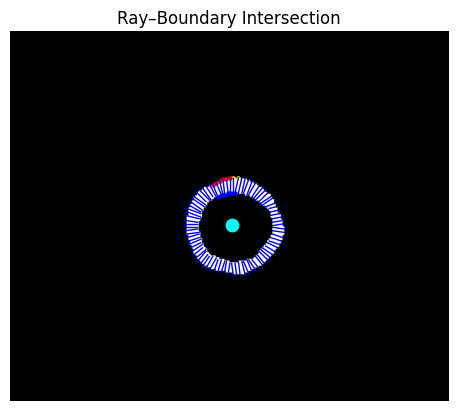

In [216]:
plt.imshow(mask, cmap='gray', origin='lower')

plt.scatter(cx, cy, c='cyan', s=80)

outer_pts = np.array(outer_pts)
inner_pts = np.array(inner_pts)

plt.scatter(outer_pts[0:2,0], outer_pts[0:2,1], c='yellow', s=5)

plt.scatter(outer_pts[2:8,0], outer_pts[2:8,1], c='red', s=5)
plt.scatter(inner_pts[0:8,0], inner_pts[0:8,1], c='blue', s=5)

for i in range(len(outer_pts)):
    plt.plot(
        [outer_pts[i][0], inner_pts[i][0]],
        [outer_pts[i][1], inner_pts[i][1]],
        'blue', linewidth=1.0
    )

plt.title("Ray–Boundary Intersection")
plt.axis('off')
plt.show()

In [217]:
outer_np = np.array(outer_pts)  # shape (N, 2)
inner_np = np.array(inner_pts)  # shape (N, 2)
diff = outer_np - inner_np
distances = np.sqrt((diff[:, 0]**2 + diff[:, 1]**2)) # euclidean distance
print(distances)

print("================")

grouped = distances.reshape(-1, 20)
group_means = grouped.mean(axis=1)
print(group_means) # get the 80 distances, group into 4 groups

[9.21954446 9.         9.         8.06225775 9.05538514 8.24621125
 7.61577311 7.61577311 8.06225775 7.21110255 8.60232527 8.48528137
 8.48528137 8.60232527 8.60232527 8.60232527 8.06225775 8.54400375
 8.54400375 8.24621125 7.07106781 7.         7.         7.07106781
 8.06225775 7.28010989 6.32455532 7.61577311 6.70820393 7.21110255
 6.40312424 7.81024968 7.81024968 6.40312424 7.21110255 8.06225775
 8.06225775 6.32455532 7.28010989 6.32455532 6.08276253 6.08276253
 7.07106781 7.07106781 8.06225775 8.24621125 7.61577311 7.61577311
 7.21110255 6.40312424 6.40312424 6.40312424 7.07106781 7.81024968
 7.21110255 5.83095189 6.70820393 6.32455532 6.32455532 6.32455532
 7.07106781 7.07106781 6.08276253 6.08276253 5.09901951 5.09901951
 4.12310563 4.12310563 5.38516481 7.21110255 7.21110255 7.07106781
 8.48528137 7.81024968 7.21110255 8.06225775 8.54400375 8.54400375
 9.21954446 9.21954446]
[8.39323227 7.15178623 6.89366965 6.93631682]


In [218]:
grouped.shape

(4, 20)